Loaded 425 records from final_violence_train.json
Loaded 108 records from final_violence_val.json
Total merged records: 533
[Saved] Merged dataset written to: final_violence_merged.json
                  DATASET METRICS SUMMARY                 
Total Images (Records)                  : 533
Total Object Annotations (BBoxes)       : 2473
Total HOI Annotations (Verbs)           : 713
Total Violence Annotations              : 765
Images with Zero Violence Annotations   : 18

[Success] Analysis histograms safely compiled and saved to: dataset_analysis_plots.png


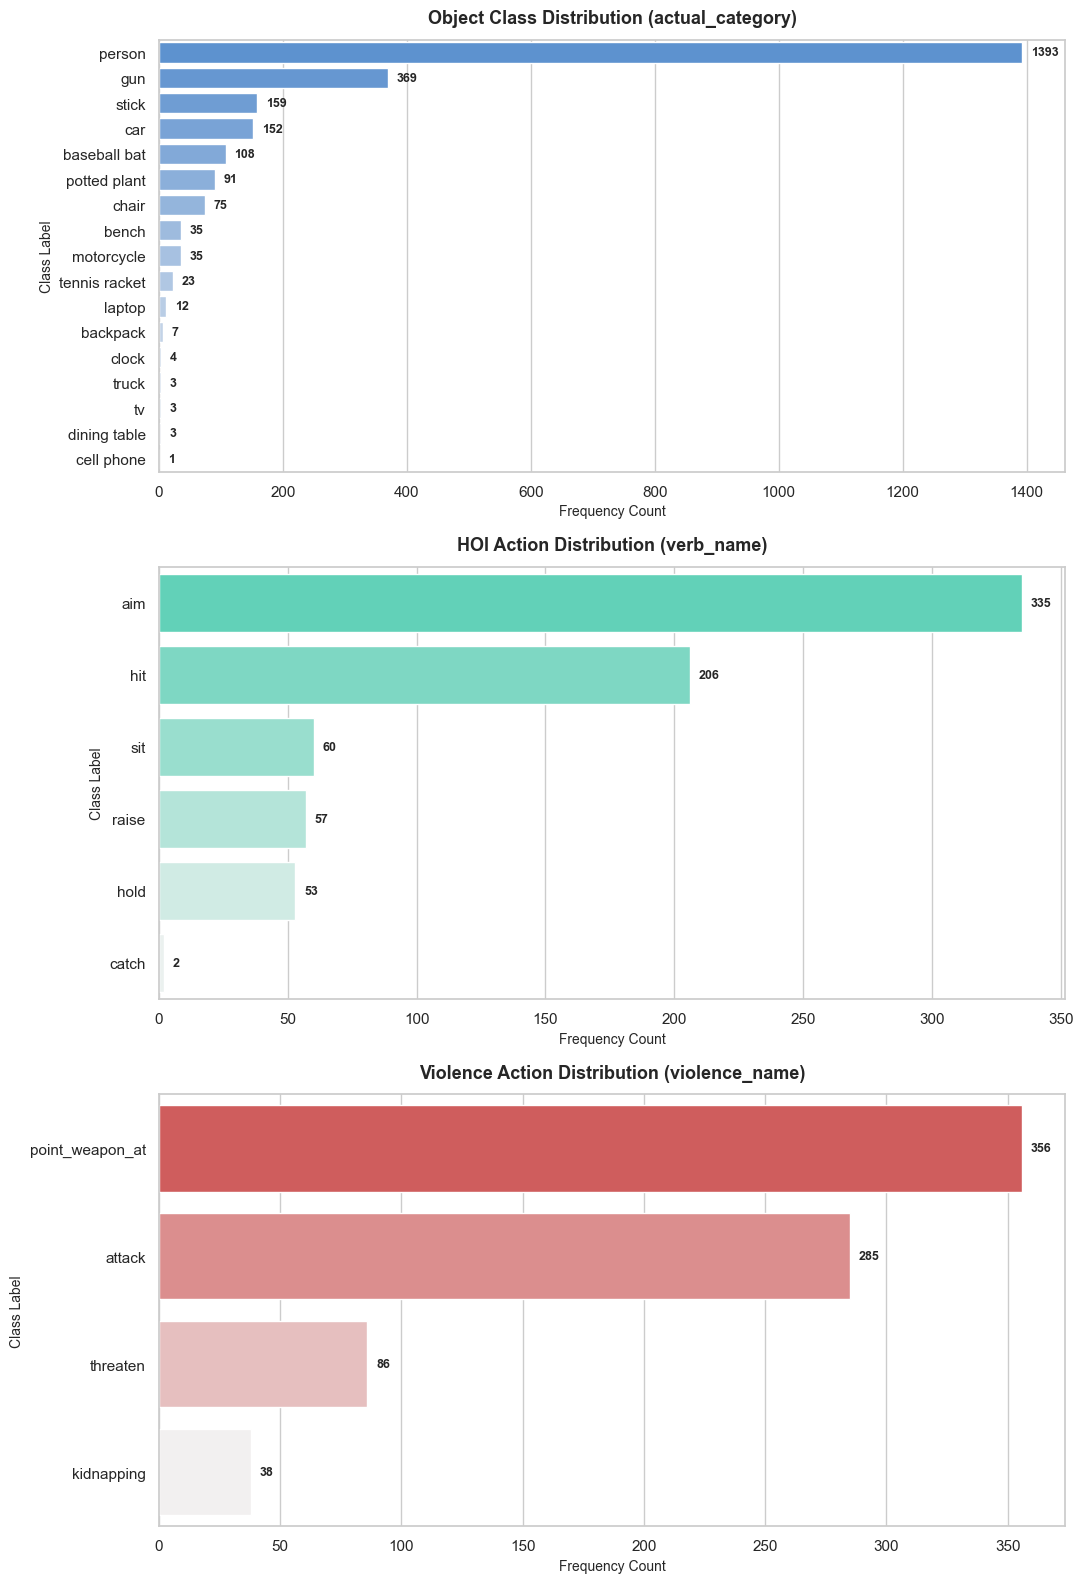

In [ ]:
import json
import os
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# ── CONFIGURATION ───────────────────────────────────────────────────────────
TRAIN_JSON_PATH = "final_violence_train.json"
VAL_JSON_PATH   = "final_violence_val.json"
MERGED_JSON_PATH = "final_violence_merged.json"
OUTPUT_PLOT_PATH = "dataset_analysis_plots.png"

def load_json(path: str) -> list:
    with open(path, "r") as f:
        data = json.load(f)
    if isinstance(data, dict):
        for key in ("data", "annotations", "images", "dataset"):
            if key in data:
                return data[key]
        raise ValueError(f"Unexpected dict structure. Keys: {list(data.keys())}")
    return data

def merge_json_files(paths: list, save_path: str = None) -> list:
    """Load multiple JSON files with the same record structure and concatenate them.
    Optionally saves the merged list to save_path."""
    merged = []
    for path in paths:
        if not os.path.exists(path):
            print(f"Warning: file not found, skipping: {path}")
            continue
        records = load_json(path)
        print(f"Loaded {len(records)} records from {os.path.basename(path)}")
        merged.extend(records)

    print(f"Total merged records: {len(merged)}")

    if save_path:
        with open(save_path, "w") as f:
            json.dump(merged, f)
        print(f"[Saved] Merged dataset written to: {save_path}")

    return merged

def extract_metrics_and_categories(records: list):
    obj_categories = []
    hoi_actions = []
    vio_actions = []

    total_images = len(records)
    total_obj_annotations = 0
    total_hoi_annotations = 0
    total_vio_annotations = 0
    empty_vio_records = 0

    for record in records:
        anns = record.get("annotations", [])
        total_obj_annotations += len(anns)
        for ann in anns:
            cat = ann.get("actual_category")
            if cat is not None:
                obj_categories.append(str(cat))

        hois = record.get("hoi_annotation", [])
        total_hoi_annotations += len(hois)
        for hoi in hois:
            verb = hoi.get("verb_name")
            if verb is not None:
                hoi_actions.append(str(verb))

        vios = record.get("violence_annotation", [])
        total_vio_annotations += len(vios)
        if not vios:
            empty_vio_records += 1
        for vio in vios:
            vio_name = vio.get("violence_name")
            if vio_name is not None:
                vio_actions.append(str(vio_name))

    print("=" * 60)
    print("                  DATASET METRICS SUMMARY                 ")
    print("=" * 60)
    print(f"{'Total Images (Records)':<40}: {total_images}")
    print(f"{'Total Object Annotations (BBoxes)':<40}: {total_obj_annotations}")
    print(f"{'Total HOI Annotations (Verbs)':<40}: {total_hoi_annotations}")
    print(f"{'Total Violence Annotations':<40}: {total_vio_annotations}")
    print(f"{'Images with Zero Violence Annotations':<40}: {empty_vio_records}")
    print("=" * 60)

    return {
        "objects": Counter(obj_categories),
        "hoi": Counter(hoi_actions),
        "violence": Counter(vio_actions)
    }

def generate_plots(data_counters: dict, output_path: str):
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(3, 1, figsize=(11, 16))

    titles = [
        "Object Class Distribution (actual_category)",
        "HOI Action Distribution (verb_name)",
        "Violence Action Distribution (violence_name)"
    ]
    keys = ["objects", "hoi", "violence"]
    colors = ["#4A90E2", "#50E3C2", "#E24A4A"]

    for i, key in enumerate(keys):
        counter = data_counters[key]
        if not counter:
            axes[i].text(0.5, 0.5, f"No Data Found for {titles[i]}",
                         ha='center', va='center', fontsize=14, color='gray')
            axes[i].set_title(titles[i], fontsize=14, fontweight='bold', pad=10)
            continue

        sorted_data = counter.most_common()
        categories = [item[0] for item in sorted_data]
        counts = [item[1] for item in sorted_data]

        sns.barplot(
            x=counts, y=categories, hue=categories,
            ax=axes[i],
            palette=sns.color_palette(f"light:{colors[i]}_r", len(counts)),
            legend=False
        )

        axes[i].set_title(titles[i], fontsize=13, fontweight='bold', pad=12)
        axes[i].set_xlabel("Frequency Count", fontsize=10)
        axes[i].set_ylabel("Class Label", fontsize=10)

        for index, value in enumerate(counts):
            axes[i].text(value + (max(counts) * 0.01), index, str(value),
                         va='center', fontsize=9, fontweight='semibold')

    plt.tight_layout()
    plt.savefig(output_path, dpi=300)
    print(f"\n[Success] Analysis histograms safely compiled and saved to: {output_path}")

def main():
    records = merge_json_files([TRAIN_JSON_PATH, VAL_JSON_PATH], save_path=MERGED_JSON_PATH)
    if not records:
        print("Error: no records loaded from either file.")
        return

    counters = extract_metrics_and_categories(records)
    generate_plots(counters, OUTPUT_PLOT_PATH)

if __name__ == "__main__":
    main()